# Visualise HMM Regime Changes

Viewer-only notebook for inspecting HMM regime changes inline. It does not create folders, save PNGs, or write summary CSVs.


In [8]:
from __future__ import annotations

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

LATENT_COLORS = {
    0: "#4575b4",
    1: "#91bfdb",
    2: "#fee090",
    3: "#d73027",
}

VOL_COLORS = {
    "low_vol": "#2a9d8f",
    "normal_vol": "#8ab17d",
    "high_vol": "#f4a261",
    "extreme_vol": "#e76f51",
}

RETURN_COLORS = {
    "downside": "#b2182b",
    "weak": "#ef8a62",
    "positive": "#67a9cf",
    "strong_upside": "#2166ac",
}

MARKET_STATE_COLORS = {
    "stress": "#b2182b",
    "upside_breakout": "#fdae61",
    "calm_positive": "#1a9850",
    "calm_negative": "#74add1",
    "chop": "#bdbdbd",
}


This cell keeps the colour mappings from `visualise_regime_changes.py`. The file-output root and non-interactive Matplotlib backend are deliberately omitted because this notebook is for inline viewing only.


In [9]:
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "raw" / "ohlcv_data.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw/ohlcv_data.csv")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"


def load_plot_panel() -> pd.DataFrame:
    labels = pd.read_csv(DATA_DIR / "hmm" / "categories" / "regime_category_labels.csv", parse_dates=["date"])
    probabilities = pd.read_csv(DATA_DIR / "hmm" / "probabilities" / "latent_regime_probabilities.csv", parse_dates=["date"])
    probability_cols = [c for c in probabilities.columns if c.startswith("hmm_regime_prob_")]
    categorical = labels.merge(
        probabilities[["date", "instrument", *probability_cols]],
        on=["date", "instrument"],
        how="left",
    )
    ohlcv = pd.read_csv(DATA_DIR / "raw" / "ohlcv_data.csv", parse_dates=["date"])
    ohlcv["instrument"] = ohlcv["instrument"].str.lower()
    panel = categorical.merge(
        ohlcv[["date", "instrument", "close"]],
        on=["date", "instrument"],
        how="left",
    )
    return panel.sort_values(["instrument", "date"])


print(f"Project root: {PROJECT_ROOT}")
panel = load_plot_panel()
print(f"Loaded {panel.shape[0]:,} rows x {panel.shape[1]} columns")
display(panel.head())


Project root: /Users/faisal/Desktop/sts
Loaded 7,095 rows x 15 columns


,date,instrument,primary_signal,hmm_predicted_regime,hmm_volatility_regime,hmm_return_regime,hmm_market_state,hmm_regime_confidence,daily_return,realized_vol_20d,hmm_regime_prob_0,hmm_regime_prob_1,hmm_regime_prob_2,hmm_regime_prob_3,close
0,2020-01-03,cl1s,0,3.0,high_vol,strong_upside,upside_breakout,0.991140,0.030566,0.009692,0.000325,7.739873e-03,7.946343e-04,9.911404e-01,25.553469
11,2020-01-06,cl1s,0,2.0,low_vol,weak,calm_negative,0.980147,0.003489,0.009648,0.012328,2.641900e-03,9.801473e-01,4.882973e-03,25.642633
22,2020-01-07,cl1s,-1,2.0,low_vol,weak,calm_negative,0.999224,-0.009009,0.009824,0.000372,3.527564e-04,9.992238e-01,5.173874e-05,25.411618
33,2020-01-08,cl1s,0,0.0,extreme_vol,downside,stress,1.000000,-0.049282,0.015258,1.000000,2.608263e-09,2.163336e-31,2.918640e-09,24.159275
44,2020-01-09,cl1s,0,2.0,low_vol,weak,calm_negative,0.979769,-0.000839,0.015245,0.007664,1.041262e-02,9.797691e-01,2.154478e-03,24.139011


This is the same data-loading logic as the script: category labels and latent probabilities are joined, then close prices are added from raw OHLCV data. Nothing is written to disk.


In [10]:
def contiguous_spans(
    frame: pd.DataFrame,
    column: str,
) -> list[tuple[pd.Timestamp, pd.Timestamp, object]]:
    changes = frame[column].ne(frame[column].shift()).cumsum()
    spans = []
    for _, block in frame.groupby(changes):
        value = block[column].iloc[0]
        if pd.isna(value):
            continue
        spans.append((block["date"].iloc[0], block["date"].iloc[-1], value))
    return spans


def plot_price_with_categories(
    frame: pd.DataFrame,
    instrument: str,
    category_col: str,
    title: str,
    colors: dict,
    legend_order: list | None,
) -> None:
    clean = frame.dropna(subset=[category_col, "close"]).copy()
    if clean.empty:
        print(f"No rows to display for {instrument.upper()} / {category_col}")
        return

    fig, ax = plt.subplots(figsize=(14, 5))
    for start, end, value in contiguous_spans(clean, category_col):
        if category_col == "hmm_predicted_regime":
            value = int(value)
        ax.axvspan(start, end, color=colors.get(value, "lightgray"), alpha=0.20, lw=0)

    ax.plot(clean["date"], clean["close"], color="#1f2933", lw=1.2)
    ax.set_title(f"{instrument.upper()} {title}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close")
    ax.grid(alpha=0.25)

    labels = legend_order or sorted(clean[category_col].dropna().unique())
    handles = [
        plt.Line2D([0], [0], color=colors.get(label, "lightgray"), lw=8, alpha=0.55, label=str(label))
        for label in labels
    ]
    ax.legend(handles=handles, ncol=min(4, len(handles)), loc="upper left", frameon=False)
    fig.tight_layout()
    plt.show()


def plot_regime_probabilities(frame: pd.DataFrame, instrument: str) -> None:
    clean = frame.dropna(subset=["close"]).copy()
    prob_cols = [c for c in clean.columns if c.startswith("hmm_regime_prob_")]
    if clean.empty or not prob_cols:
        print(f"No probability rows to display for {instrument.upper()}")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(clean["date"], clean["close"], color="#1f2933", lw=1.2)
    axes[0].set_title(f"{instrument.upper()} close price and HMM regime probabilities")
    axes[0].set_ylabel("Close")
    axes[0].grid(alpha=0.25)

    x = clean["date"]
    bottom = None
    for col in prob_cols:
        label = col.replace("hmm_regime_prob_", "Regime ")
        values = clean[col].fillna(0)
        if bottom is None:
            axes[1].fill_between(x, 0, values, alpha=0.75, label=label)
            bottom = values.copy()
        else:
            top = bottom + values
            axes[1].fill_between(x, bottom, top, alpha=0.75, label=label)
            bottom = top
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Probability")
    axes[1].set_xlabel("Date")
    axes[1].grid(alpha=0.25)
    axes[1].legend(ncol=4, loc="upper left", frameon=False)
    fig.tight_layout()
    plt.show()


These are the plotting functions from the script adapted for inline viewing. The plotting logic is the same, but the `output_path` parameter and `fig.savefig(...)` calls are removed so figures display in the notebook only.


In [11]:
def make_summary(panel: pd.DataFrame, group_col: str) -> pd.DataFrame:
    frame = panel.dropna(subset=[group_col]).copy()
    frame["regime_switch"] = frame.groupby("instrument")[group_col].transform(lambda s: s.ne(s.shift()))
    summary = (
        frame.groupby(["instrument", group_col])
        .agg(
            days=("date", "count"),
            avg_confidence=("hmm_regime_confidence", "mean"),
            avg_daily_return=("daily_return", "mean"),
            avg_realized_vol_20d=("realized_vol_20d", "mean"),
            switches=("regime_switch", "sum"),
        )
        .reset_index()
        .sort_values(["instrument", group_col])
    )
    return summary


The summary helper is kept for notebook inspection. It returns a dataframe for display and does not save any CSV files.


In [12]:
instruments = sorted(panel["instrument"].dropna().unique())
print(instruments)


['cl1s', 'es1s', 'fesx1s', 'gc1s', 'hg1s', 'ho1s', 'ng1s', 'nq1s', 'pl1s', 'rb1s', 'si1s']


Use the instrument list to choose what to view. The next cell renders all four category overlays plus the latent-regime probability stack for one selected instrument.


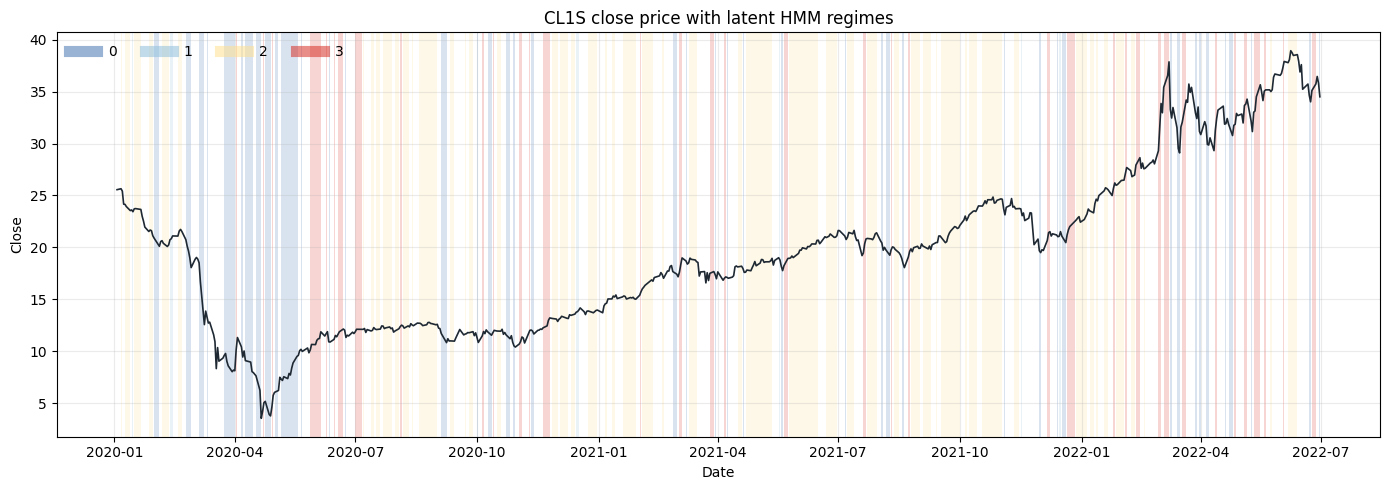

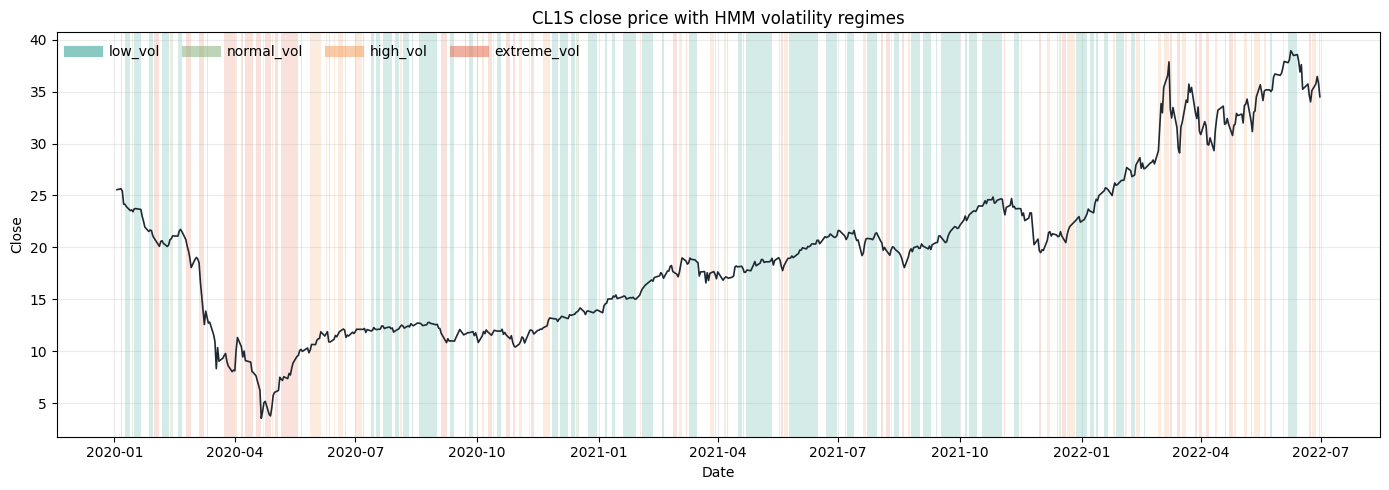

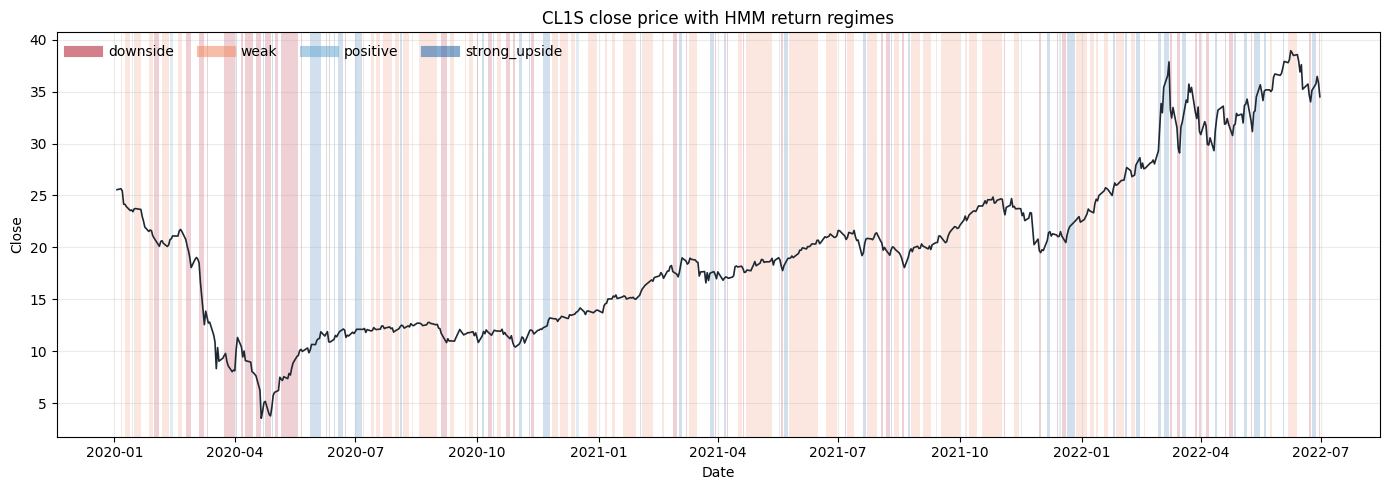

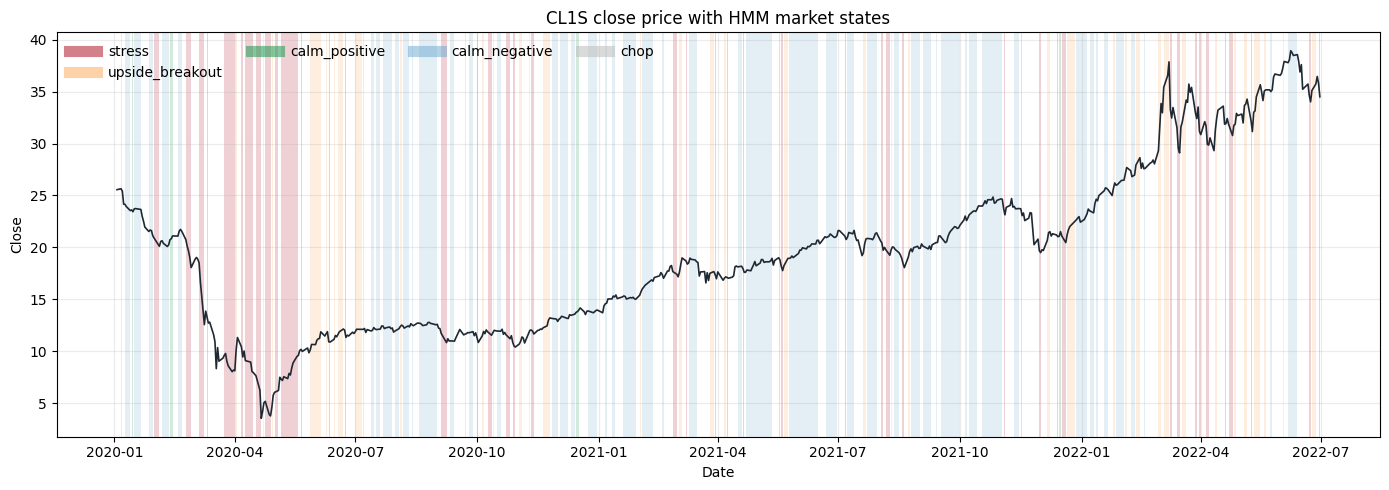

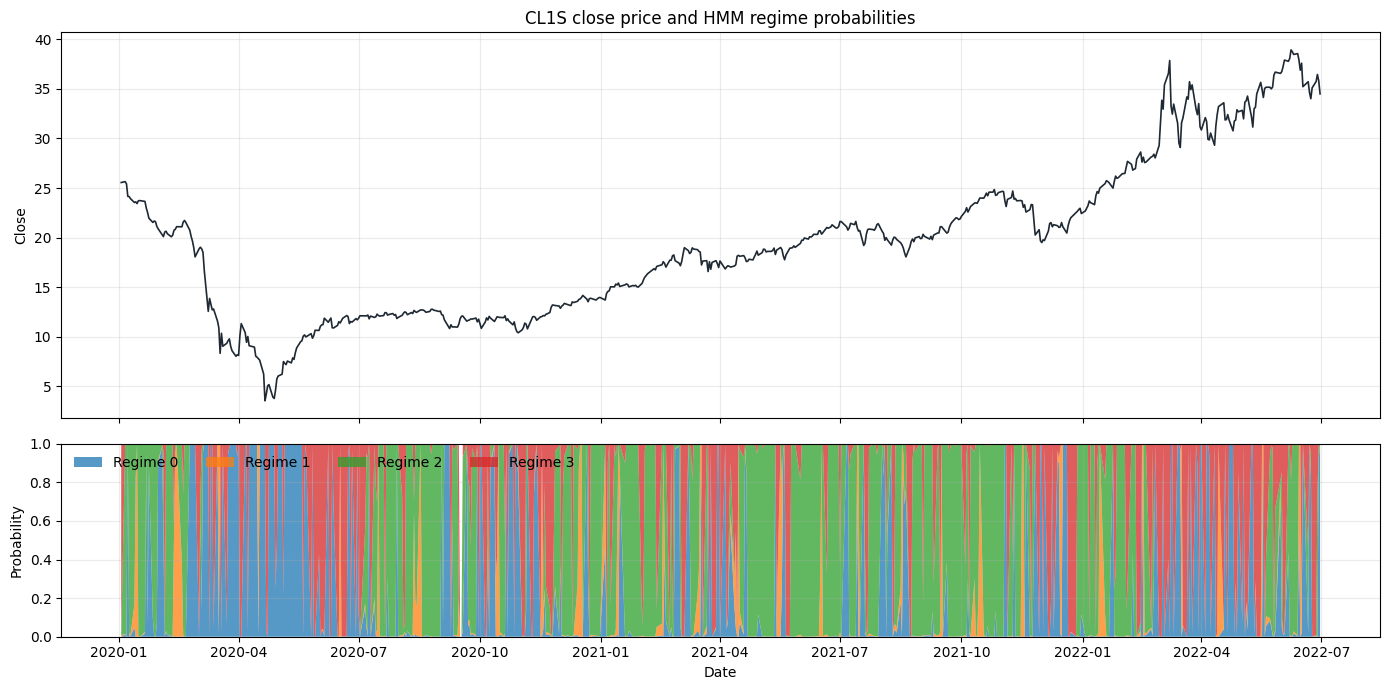

In [13]:
selected_instrument = "cl1s"
frame = panel[panel["instrument"] == selected_instrument]

plot_price_with_categories(
    frame,
    selected_instrument,
    "hmm_predicted_regime",
    "close price with latent HMM regimes",
    LATENT_COLORS,
    [0, 1, 2, 3],
)
plot_price_with_categories(
    frame,
    selected_instrument,
    "hmm_volatility_regime",
    "close price with HMM volatility regimes",
    VOL_COLORS,
    ["low_vol", "normal_vol", "high_vol", "extreme_vol"],
)
plot_price_with_categories(
    frame,
    selected_instrument,
    "hmm_return_regime",
    "close price with HMM return regimes",
    RETURN_COLORS,
    ["downside", "weak", "positive", "strong_upside"],
)
plot_price_with_categories(
    frame,
    selected_instrument,
    "hmm_market_state",
    "close price with HMM market states",
    MARKET_STATE_COLORS,
    ["stress", "upside_breakout", "calm_positive", "calm_negative", "chop"],
)
plot_regime_probabilities(frame, selected_instrument)


Change `selected_instrument` and rerun the cell to view a different market. The plots are rendered inline only.


In [14]:
display(make_summary(panel, "hmm_predicted_regime"))
display(make_summary(panel, "hmm_volatility_regime"))
display(make_summary(panel, "hmm_return_regime"))
display(make_summary(panel, "hmm_market_state"))


,instrument,hmm_predicted_regime,days,avg_confidence,avg_daily_return,avg_realized_vol_20d,switches
0,cl1s,0.0,162,0.945576,-0.034663,0.052294,90
1,cl1s,1.0,39,0.929499,0.002572,0.025246,31
2,cl1s,2.0,261,0.935294,0.001432,0.017960,77
3,cl1s,3.0,164,0.914863,0.037077,0.037252,106
4,es1s,0.0,120,0.938619,-0.002673,0.025574,27
5,es1s,1.0,259,0.933277,0.000983,0.011976,51
6,es1s,2.0,35,0.948385,0.001262,0.009128,12
7,es1s,3.0,215,0.951955,0.001277,0.006735,30
8,fesx1s,0.0,48,0.928676,-0.001742,0.013119,14
9,fesx1s,1.0,107,0.936213,-0.002669,0.025590,19


,instrument,hmm_volatility_regime,days,avg_confidence,avg_daily_return,avg_realized_vol_20d,switches
0,cl1s,extreme_vol,162,0.945576,-0.034663,0.052294,90
1,cl1s,high_vol,164,0.914863,0.037077,0.037252,106
2,cl1s,low_vol,261,0.935294,0.001432,0.017960,77
3,cl1s,normal_vol,39,0.929499,0.002572,0.025246,31
4,es1s,extreme_vol,120,0.938619,-0.002673,0.025574,27
5,es1s,high_vol,259,0.933277,0.000983,0.011976,51
6,es1s,low_vol,215,0.951955,0.001277,0.006735,30
7,es1s,normal_vol,35,0.948385,0.001262,0.009128,12
8,fesx1s,extreme_vol,107,0.936213,-0.002669,0.025590,19
9,fesx1s,high_vol,259,0.941255,0.001201,0.013860,33


,instrument,hmm_return_regime,days,avg_confidence,avg_daily_return,avg_realized_vol_20d,switches
0,cl1s,downside,162,0.945576,-0.034663,0.052294,90
1,cl1s,positive,39,0.929499,0.002572,0.025246,31
2,cl1s,strong_upside,164,0.914863,0.037077,0.037252,106
3,cl1s,weak,261,0.935294,0.001432,0.017960,77
4,es1s,downside,120,0.938619,-0.002673,0.025574,27
5,es1s,positive,35,0.948385,0.001262,0.009128,12
6,es1s,strong_upside,215,0.951955,0.001277,0.006735,30
7,es1s,weak,259,0.933277,0.000983,0.011976,51
8,fesx1s,downside,107,0.936213,-0.002669,0.025590,19
9,fesx1s,positive,221,0.956593,0.000872,0.008226,24


,instrument,hmm_market_state,days,avg_confidence,avg_daily_return,avg_realized_vol_20d,switches
0,cl1s,calm_negative,261,0.935294,0.001432,0.017960,77
1,cl1s,calm_positive,39,0.929499,0.002572,0.025246,31
2,cl1s,stress,162,0.945576,-0.034663,0.052294,90
3,cl1s,upside_breakout,164,0.914863,0.037077,0.037252,106
4,es1s,calm_positive,250,0.951455,0.001274,0.007070,30
5,es1s,stress,379,0.934968,-0.000175,0.016282,30
6,fesx1s,calm_negative,48,0.928676,-0.001742,0.013119,14
7,fesx1s,calm_positive,221,0.956593,0.000872,0.008226,24
8,fesx1s,stress,107,0.936213,-0.002669,0.025590,19
9,fesx1s,upside_breakout,259,0.941255,0.001201,0.013860,33


These summary tables are for inspection inside the notebook only. They are not written to disk.
